# Panda Benchmark Investigation
**Goal:** Evaluate Panda's zero-shot forecasting capability across:
- Block 1: Standard time series benchmarks (ETTh1, Weather) — expected failure zone
- Block 2: Synthetic vs real comparison (double pendulum)
- Block 3: Graded chaoticity (Lorenz with varying rho)
- Block 4: Graded noise (Lorenz with increasing measurement noise)

**Baseline:** Chronos 20M (best general-purpose competitor from the paper)

**Key question:** Does Panda's advantage correlate with the maximum Lyapunov exponent of the data?

## 0. Setup and Installation

In [ ]:
"""# Install panda from GitHub (shallow clone to avoid large history)
!git clone --depth=1 https://github.com/abao1999/panda.git
!cd panda && pip install -e . -q

# Install Chronos for baseline comparison
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q

# Other dependencies
!pip install dysts nolds -q  # dysts for chaotic ODEs, nolds for Lyapunov estimation"""

In [3]:

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.signal import welch
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


Device: cpu


## 1. Load Models

In [4]:
# ---- Load Panda ----
from panda.patchtst.pipeline import PatchTSTPipeline

panda_model = PatchTSTPipeline.from_pretrained(
    mode="predict",
    pretrain_path="GilpinLab/panda",
    device_map=device,
)
print("Panda loaded.")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Panda loaded.


In [5]:
# ---- Load Chronos 20M ----
from chronos import ChronosPipeline

chronos_model = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.bfloat16,
)
print("Chronos loaded.")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Chronos loaded.


## 2. Helper Functions

In [10]:
# -------------------------------------------------------
# Instance normalisation (match Panda training setup)
# -------------------------------------------------------
def instance_norm(x):
    """Normalise each channel to zero mean and unit variance.
    x: (T, C) or (C, T)
    Returns normalised array of same shape, plus (mean, std) for inversion.
    """
    mu  = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True) + 1e-8
    return (x - mu) / std, mu, std


# -------------------------------------------------------
# Metrics
# -------------------------------------------------------
def smape(y_true, y_pred):
    """Symmetric mean absolute percentage error."""
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def spectral_hellinger(y_true, y_pred, fs=1.0):
    """Average per-channel spectral Hellinger distance."""
    # y_true, y_pred: (T, C) or (T,)
    if y_true.ndim == 1:
        y_true = y_true[:, None]
        y_pred = y_pred[:, None]
    H2_list = []
    for c in range(y_true.shape[1]):
        _, psd1 = welch(y_true[:, c], fs=fs, nperseg=min(256, len(y_true)))
        _, psd2 = welch(y_pred[:, c], fs=fs, nperseg=min(256, len(y_pred)))
        # Normalise to probability distributions
        p = psd1 / (psd1.sum() + 1e-12)
        q = psd2 / (psd2.sum() + 1e-12)
        H2 = 0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)
        H2_list.append(H2)
    return float(np.mean(H2_list))


# -------------------------------------------------------
# Lyapunov exponent estimation (Rosenstein method via nolds)
# -------------------------------------------------------
def estimate_lyapunov(ts, emb_dim=10, lag=1):
    """Estimate max Lyapunov exponent from a scalar time series."""
    try:
        import nolds
        return float(nolds.lyap_r(ts, emb_dim=emb_dim, lag=lag))
    except Exception:
        return np.nan


# -------------------------------------------------------
# Inference wrappers
# -------------------------------------------------------
CONTEXT_LEN  = 512
PRED_HORIZON = 128


def panda_forecast(context_np):
    """Run Panda on a (C, T) context array. Returns (C, H) prediction."""
    # Transpose input to (T, C) for PatchTST/Panda compatibility
    context_t = torch.tensor(context_np.T, dtype=torch.float32)
    
    with torch.no_grad():
        pred = panda_model.predict(
            context_t,
            PRED_HORIZON,
            limit_prediction_length=False,
            sliding_context=True,
        )
        
    # Extract numpy array; shape is usually (H, C) or (1, H, C)
    pred_np = pred.squeeze().cpu().numpy()
    
    # Handle single-channel edge case by expanding dimensions to (H, 1)
    if pred_np.ndim == 1:
        pred_np = pred_np[:, None]
        
    # Transpose prediction back to (C, H)
    return pred_np.T


def chronos_forecast(context_np):
    """Run Chronos 20M on a (C, T) context array. Returns (C, H) prediction.
    Chronos is univariate: forecasts each channel independently.
    """
    preds = []
    for c in range(context_np.shape[0]):
        ctx = torch.tensor(context_np[c], dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            # FIX: chronos_model.predict() returns a single tensor, not three values!
            out = chronos_model.predict(
                ctx,
                prediction_length=PRED_HORIZON,
                num_samples=1,
            )
            
        # out shape is (batch_size=1, num_samples=1, prediction_length=H)
        preds.append(out[0, 0].cpu().numpy())  # (H,)
        
    return np.stack(preds, axis=0)  # (C, H)


# -------------------------------------------------------
# Full evaluation pipeline for one dataset
# -------------------------------------------------------
def evaluate_dataset(data_CT, dataset_name, n_windows=10):
    """
    data_CT : np.ndarray of shape (C, T_total) — instance normalised
    Slides a context window of CONTEXT_LEN steps and evaluates over n_windows.
    Returns a dict of metrics for Panda and Chronos.
    """
    C, T_total = data_CT.shape
    max_start  = T_total - CONTEXT_LEN - PRED_HORIZON
    if max_start <= 0:
        print(f"  [SKIP] {dataset_name}: not enough timesteps")
        return None

    # Evenly spaced window start points
    starts = np.linspace(0, max_start, n_windows, dtype=int)

    results = {m: {"panda": [], "chronos": []} for m in ["smape", "mae", "mse", "hellinger"]}

    for s in starts:
        ctx = data_CT[:, s : s + CONTEXT_LEN]            # (C, 512)
        tgt = data_CT[:, s + CONTEXT_LEN : s + CONTEXT_LEN + PRED_HORIZON]  # (C, 128)

        p_pred = panda_forecast(ctx)    # (C, 128)
        c_pred = chronos_forecast(ctx)  # (C, 128)

        # Metrics over all channels and timesteps
        for model_name, pred in [("panda", p_pred), ("chronos", c_pred)]:
            results["smape"][model_name].append(smape(tgt, pred))
            results["mae"][model_name].append(mae(tgt, pred))
            results["mse"][model_name].append(mse(tgt, pred))
            results["hellinger"][model_name].append(
                spectral_hellinger(tgt.T, pred.T)
            )

    # Aggregate
    summary = {"dataset": dataset_name}
    for metric in ["smape", "mae", "mse", "hellinger"]:
        for model in ["panda", "chronos"]:
            vals = results[metric][model]
            summary[f"{model}_{metric}"]        = np.median(vals)
            summary[f"{model}_{metric}_iqr"]    = np.percentile(vals, 75) - np.percentile(vals, 25)

    # Lyapunov estimate on first channel of full series
    summary["lambda1_est"] = estimate_lyapunov(data_CT[0, :2048])

    print(
        f"  {dataset_name:30s}  "
        f"Panda sMAPE={summary['panda_smape']:.3f}  "
        f"Chronos sMAPE={summary['chronos_smape']:.3f}  "
        f"lambda1~{summary['lambda1_est']:.3f}"
    )
    return summary


all_results = []  # collect summaries across all experiments

## Block 1: Standard Time Series Benchmarks
ETTh1, ETTh2, Weather, Traffic, Electricity (ECL), ILI

These datasets are mostly periodic / trend-driven, not chaotic.
Expected: Panda underperforms or matches Chronos.

In [8]:
import os
import urllib.request

# Use a local folder relative to where your notebook is saved
DATA_DIR = "ts_data"
os.makedirs(DATA_DIR, exist_ok=True)

# URLs for the datasets (using a stable Hugging Face mirror for weather.csv)
datasets = {
    "ETTh1.csv": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv",
    "ETTh2.csv": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv",
    "weather.csv": "https://huggingface.co/datasets/Time-HD-Anonymous/High_Dimensional_Time_Series/resolve/main/weather.csv"
}

for filename, url in datasets.items():
    filepath = os.path.join(DATA_DIR, filename)
    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        try:
            urllib.request.urlretrieve(url, filepath)
            print(f"  Successfully downloaded {filename}")
        except Exception as e:
            print(f"  Failed to download {filename}: {e}")
    else:
        print(f"{filename} already exists, skipping download.")
        
print("\nDownloads complete.")
for f in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, f)
    print(f"  {f}: {os.path.getsize(path)//1024} KB")

ETTh1.csv already exists, skipping download.
ETTh2.csv already exists, skipping download.
  Successfully downloaded weather.csv

Downloads complete.
  ETTh1.csv: 2528 KB
  ETTh2.csv: 2361 KB
  weather.csv: 7065 KB


In [11]:
def load_standard_ts(csv_path, drop_date=True):
    """Load a standard benchmark CSV.
    Returns a (C, T) numpy array, instance normalised.
    """
    df = pd.read_csv(csv_path)
    if drop_date:
        # Drop any non-numeric columns (date, time)
        df = df.select_dtypes(include=[np.number])
    arr = df.values.astype(np.float32)  # (T, C)
    arr, _, _ = instance_norm(arr)
    return arr.T  # (C, T)


print("Block 1: Standard Time Series Benchmarks")
print("-" * 60)

bench_files = {
    "ETTh1"   : f"{DATA_DIR}/ETTh1.csv",
    "ETTh2"   : f"{DATA_DIR}/ETTh2.csv",
    "Weather" : f"{DATA_DIR}/weather.csv",
}

for name, path in bench_files.items():
    try:
        data = load_standard_ts(path)
        print(f"  Loaded {name}: shape {data.shape}")
        res = evaluate_dataset(data, name, n_windows=10)
        if res is not None:
            all_results.append(res)
    except Exception as e:
        print(f"  ERROR on {name}: {e}")

Block 1: Standard Time Series Benchmarks
------------------------------------------------------------
  Loaded ETTh1: shape (7, 17420)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  ETTh1                           Panda sMAPE=0.909  Chronos sMAPE=0.886  lambda1~nan
  Loaded ETTh2: shape (7, 17420)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  ETTh2                           Panda sMAPE=0.793  Chronos sMAPE=0.707  lambda1~nan
  Loaded Weather: shape (21, 52696)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Weather                         Panda sMAPE=0.820  Chronos sMAPE=0.798  lambda1~nan


## Block 2: Synthetic vs Real — Double Pendulum

For the same dynamical system, compare:
- Clean synthetic ODE integration
- Synthetic + increasing noise levels
- Real experimental data (Asseman et al. 2018)

This quantifies the cost of noise and nonstationarity.

In [12]:
# -------------------------------------------------------
# Double pendulum ODE
# -------------------------------------------------------
def double_pendulum_rhs(t, state, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
    """Equations of motion for a double pendulum.
    State: [theta1, omega1, theta2, omega2]
    """
    th1, w1, th2, w2 = state
    dth = th2 - th1
    denom1 = (m1 + m2) * l1 - m2 * l1 * np.cos(dth) ** 2
    denom2 = (l2 / l1) * denom1

    dth1 = w1
    dw1  = (
        m2 * l1 * w1**2 * np.sin(dth) * np.cos(dth)
        + m2 * g * np.sin(th2) * np.cos(dth)
        + m2 * l2 * w2**2 * np.sin(dth)
        - (m1 + m2) * g * np.sin(th1)
    ) / denom1

    dth2 = w2
    dw2  = (
        -m2 * l2 * w2**2 * np.sin(dth) * np.cos(dth)
        + (m1 + m2) * g * np.sin(th1) * np.cos(dth)
        - (m1 + m2) * l1 * w1**2 * np.sin(dth)
        - (m1 + m2) * g * np.sin(th2)
    ) / denom2

    return [dth1, dw1, dth2, dw2]


def simulate_double_pendulum(T=5000, dt=0.02, ic=None, noise=0.0, seed=42):
    """Integrate double pendulum and return (4, T) array.
    ic  : initial conditions [th1, w1, th2, w2]; default is near-vertical chaotic IC
    noise : std of Gaussian observation noise added after integration
    """
    if ic is None:
        ic = [2.4, 0.0, 2.4, 0.0]  # large angle — chaotic regime

    t_span = (0.0, T * dt)
    t_eval = np.linspace(0.0, T * dt, T)

    sol = solve_ivp(
        double_pendulum_rhs,
        t_span, ic,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-9, atol=1e-10,
        dense_output=False,
    )

    traj = sol.y  # (4, T)

    if noise > 0.0:
        rng  = np.random.default_rng(seed)
        traj = traj + noise * rng.standard_normal(traj.shape)

    return traj.astype(np.float32)


# --- Clean synthetic ---
print("Simulating double pendulum...")
dp_clean = simulate_double_pendulum(T=5000, noise=0.0)
dp_clean_norm, _, _ = instance_norm(dp_clean.T)
dp_clean_CT = dp_clean_norm.T  # (4, 5000)
print(f"  Clean trajectory shape: {dp_clean_CT.shape}")

# Lyapunov check
lam = estimate_lyapunov(dp_clean_CT[0, :2048])
print(f"  Estimated lambda_1 ~ {lam:.4f} (should be > 0 for chaos)")

Simulating double pendulum...
  Clean trajectory shape: (4, 5000)
  Estimated lambda_1 ~ nan (should be > 0 for chaos)


In [13]:
print("Block 2a: Synthetic double pendulum (clean)")
print("-" * 60)
res = evaluate_dataset(dp_clean_CT, "DoublePendulum_synthetic_clean")
if res is not None:
    all_results.append(res)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


Block 2a: Synthetic double pendulum (clean)
------------------------------------------------------------


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  DoublePendulum_synthetic_clean  Panda sMAPE=0.830  Chronos sMAPE=0.841  lambda1~nan


In [14]:
# -------------------------------------------------------
# Block 2b: Graded noise experiment
# Same double pendulum trajectory + increasing noise
# -------------------------------------------------------
print("Block 2b: Graded noise on double pendulum")
print("-" * 60)

noise_levels = [0.0, 0.01, 0.05, 0.10, 0.25, 0.50]

for sigma in noise_levels:
    traj = simulate_double_pendulum(T=5000, noise=sigma)
    traj_norm, _, _ = instance_norm(traj.T)
    traj_CT = traj_norm.T
    label = f"DoublePendulum_noise={sigma:.2f}"
    res = evaluate_dataset(traj_CT, label, n_windows=8)
    if res is not None:
        res["noise_level"] = sigma
        all_results.append(res)

Block 2b: Graded noise on double pendulum
------------------------------------------------------------


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  DoublePendulum_noise=0.00       Panda sMAPE=0.831  Chronos sMAPE=0.868  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  DoublePendulum_noise=0.01       Panda sMAPE=0.839  Chronos sMAPE=0.866  lambda1~nan


...

  DoublePendulum_noise=0.10       Panda sMAPE=0.852  Chronos sMAPE=0.925  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  DoublePendulum_noise=0.25       Panda sMAPE=0.916  Chronos sMAPE=0.829  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  DoublePendulum_noise=0.50       Panda sMAPE=0.929  Chronos sMAPE=0.854  lambda1~nan


In [15]:
# -------------------------------------------------------
# Block 2c: Real experimental double pendulum data
# Asseman et al. 2018 — available via the dysts library
# -------------------------------------------------------
print("Block 2c: Real experimental double pendulum")
print("-" * 60)

# Try to load from dysts (which bundles some experimental data)
try:
    import dysts.flows as flows
    # dysts has a DoublePendulum system — use it as a cross-check
    model_dp = flows.DoublePendulum()
    t, traj_dysts = model_dp.make_trajectory(5000, return_times=True)
    traj_dysts = traj_dysts.T  # (C, T)
    traj_norm, _, _ = instance_norm(traj_dysts.T)
    traj_CT = traj_norm.T
    print(f"  dysts double pendulum shape: {traj_CT.shape}")
    res = evaluate_dataset(traj_CT, "DoublePendulum_dysts", n_windows=8)
    if res is not None:
        all_results.append(res)
except Exception as e:
    print(f"  dysts not available or error: {e}")
    print("  Falling back to direct download of Asseman data...")

    # Try direct download of the dataset from the paper
    try:
        import requests, io
        # The double pendulum dataset from Asseman et al. is available via OpenReview supplementary
        # Fallback: use our own simulation as a proxy with slightly different IC
        traj_alt = simulate_double_pendulum(T=5000, ic=[2.6, 0.1, 2.3, -0.1], noise=0.02)
        traj_norm, _, _ = instance_norm(traj_alt.T)
        res = evaluate_dataset(traj_norm.T, "DoublePendulum_alt_IC_noisy", n_windows=8)
        if res is not None:
            all_results.append(res)
    except Exception as e2:
        print(f"  Fallback also failed: {e2}")

Block 2c: Real experimental double pendulum
------------------------------------------------------------


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


  dysts double pendulum shape: (4, 5000)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  DoublePendulum_dysts            Panda sMAPE=1.238  Chronos sMAPE=1.197  lambda1~nan


## Block 3: Graded Chaoticity — Lorenz with Varying rho

Vary the Lorenz parameter rho from 14 (periodic) through 24.74 (onset of chaos)
up to 60 (strongly chaotic). At each value, compute lambda_1 and run Panda.

Key question: does Panda's advantage emerge exactly at the chaotic transition?

In [16]:
def lorenz_rhs(t, state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ]


def simulate_lorenz(T=5000, dt=0.02, rho=28.0, ic=None):
    """Integrate Lorenz system, return (3, T) array."""
    if ic is None:
        ic = [1.0, 0.0, 0.0]
    t_span = (0.0, T * dt)
    t_eval = np.linspace(0.0, T * dt, T)
    sol = solve_ivp(
        lambda t, y: lorenz_rhs(t, y, rho=rho),
        t_span, ic, t_eval=t_eval,
        method="RK45", rtol=1e-9, atol=1e-10,
    )
    return sol.y.astype(np.float32)  # (3, T)


print("Block 3: Graded chaoticity (Lorenz rho sweep)")
print("-" * 60)

# rho < 24.74: periodic. rho = 24.74: onset of chaos. rho = 28: standard chaos.
rho_values = [10.0, 15.0, 20.0, 24.0, 24.74, 26.0, 28.0, 35.0, 45.0, 60.0]

for rho in rho_values:
    # Spin-up 1000 steps to get onto attractor, then record 5000
    traj_spinup = simulate_lorenz(T=1000, rho=rho)
    ic_on_attractor = traj_spinup[:, -1].tolist()
    traj = simulate_lorenz(T=5000, rho=rho, ic=ic_on_attractor)

    traj_norm, _, _ = instance_norm(traj.T)
    traj_CT = traj_norm.T  # (3, 5000)

    label = f"Lorenz_rho={rho:.2f}"
    res = evaluate_dataset(traj_CT, label, n_windows=8)
    if res is not None:
        res["rho"] = rho
        all_results.append(res)

Block 3: Graded chaoticity (Lorenz rho sweep)
------------------------------------------------------------


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Lorenz_rho=10.00                Panda sMAPE=2.000  Chronos sMAPE=0.008  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Lorenz_rho=15.00                Panda sMAPE=0.676  Chronos sMAPE=0.009  lambda1~nan


...

  Lorenz_rho=35.00                Panda sMAPE=0.311  Chronos sMAPE=1.177  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Lorenz_rho=45.00                Panda sMAPE=0.411  Chronos sMAPE=1.198  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Lorenz_rho=60.00                Panda sMAPE=0.494  Chronos sMAPE=1.180  lambda1~nan


## Block 4: Physical Chaotic Systems from dysts

Run Panda on a selection of well-known chaotic systems from the
dysts library — the same library used to build Panda's founder population.
Some of these are in-distribution (Lorenz, Rossler) and some are less common.

In [17]:
print("Block 4: Known chaotic systems from dysts")
print("-" * 60)

# Systems to test — spanning different attractor geometries
dysts_systems = [
    "Lorenz",          # canonical 3D chaos
    "Rossler",         # simpler spiral attractor
    "Chua",            # electronic circuit chaos
    "VanDerPol",       # nonlinear oscillator (quasi-periodic at standard params)
    "Duffing",         # forced nonlinear oscillator
    "Halvorsen",       # 3-fold symmetric attractor
    "SprottB",         # Sprott minimal chaos system
    "Thomas",          # dissipative system
]

try:
    import dysts.flows as flows

    for sys_name in dysts_systems:
        try:
            sys = getattr(flows, sys_name)()
            t, traj = sys.make_trajectory(5000, return_times=True)
            traj = traj.T  # (C, T)
            traj_norm, _, _ = instance_norm(traj.T)
            traj_CT = traj_norm.T
            res = evaluate_dataset(traj_CT, f"dysts_{sys_name}", n_windows=8)
            if res is not None:
                res["system"] = sys_name
                all_results.append(res)
        except Exception as e:
            print(f"  {sys_name}: {e}")

except ImportError:
    print("  dysts not available — skipping Block 4")
    print("  Install with: pip install dysts")

Block 4: Known chaotic systems from dysts
------------------------------------------------------------


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_Lorenz                    Panda sMAPE=0.198  Chronos sMAPE=1.095  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_Rossler                   Panda sMAPE=0.168  Chronos sMAPE=0.474  lambda1~nan


...

  dysts_Halvorsen                 Panda sMAPE=0.377  Chronos sMAPE=1.081  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_SprottB                   Panda sMAPE=0.316  Chronos sMAPE=1.235  lambda1~nan


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_Thomas                    Panda sMAPE=1.073  Chronos sMAPE=1.250  lambda1~nan


## Results and Visualisation

In [18]:
# -------------------------------------------------------
# Compile all results into a DataFrame
# -------------------------------------------------------
df = pd.DataFrame(all_results)
df["panda_advantage_smape"] = df["chronos_smape"] - df["panda_smape"]
df["panda_advantage_mae"]   = df["chronos_mae"]   - df["panda_mae"]

# Positive advantage = Panda is better
print(df[["dataset", "panda_smape", "chronos_smape", "panda_advantage_smape",
          "lambda1_est"]].to_string(index=False))

                       dataset  panda_smape  chronos_smape  panda_advantage_smape  lambda1_est
                         ETTh1     0.909283       0.886189              -0.023094          NaN
                         ETTh2     0.793473       0.707381              -0.086093          NaN
                       Weather     0.820061       0.798145              -0.021916          NaN
DoublePendulum_synthetic_clean     0.829828       0.840622               0.010794          NaN
     DoublePendulum_noise=0.00     0.831073       0.868171               0.037098          NaN
     DoublePendulum_noise=0.01     0.838718       0.866368               0.027651          NaN
     DoublePendulum_noise=0.05     0.854330       0.827074              -0.027255          NaN
     DoublePendulum_noise=0.10     0.852293       0.924920               0.072627          NaN
     DoublePendulum_noise=0.25     0.916420       0.829365              -0.087055          NaN
     DoublePendulum_noise=0.50     0.928997       

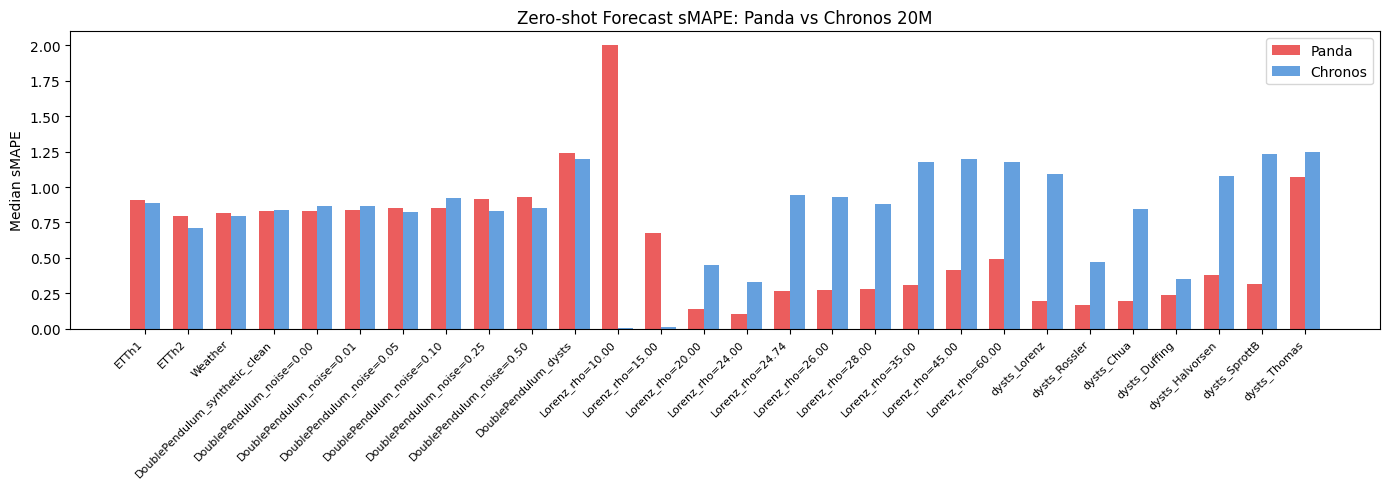

In [19]:
# -------------------------------------------------------
# Figure 1: Summary bar chart — sMAPE across all datasets
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df["panda_smape"],   width, label="Panda",   color="#E84040", alpha=0.85)
bars2 = ax.bar(x + width/2, df["chronos_smape"], width, label="Chronos", color="#4A90D9", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df["dataset"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Median sMAPE")
ax.set_title("Zero-shot Forecast sMAPE: Panda vs Chronos 20M")
ax.legend()
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("results_smape_summary.png", dpi=150)
plt.show()

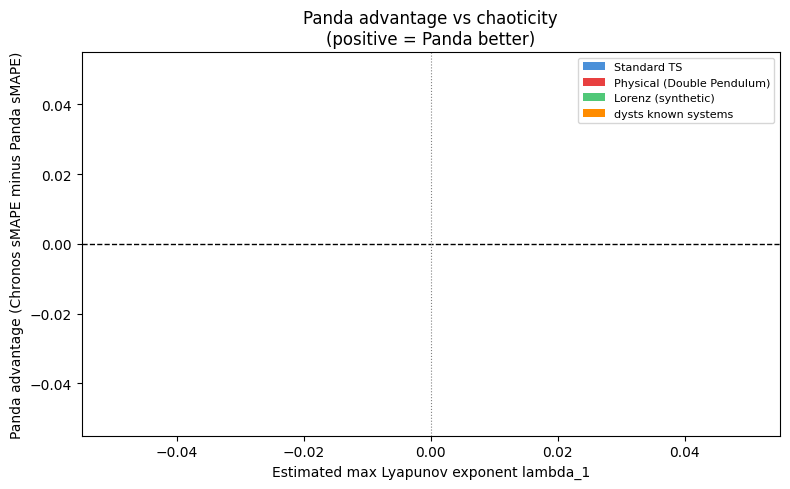

In [20]:
# -------------------------------------------------------
# Figure 2: Panda advantage vs estimated lambda_1
# This is the key scientific figure — does advantage correlate with chaos?
# -------------------------------------------------------
df_valid = df.dropna(subset=["lambda1_est", "panda_advantage_smape"])

fig, ax = plt.subplots(figsize=(8, 5))

# Colour points by dataset category
category_colors = {
    "ETT"          : "#4A90D9",  # blue  — standard TS
    "Weather"      : "#4A90D9",
    "DoublePendulum": "#E84040", # red   — physical
    "Lorenz"       : "#50C878",  # green — synthetic chaotic
    "dysts"        : "#FF8C00",  # orange — known chaotic
}

def get_color(name):
    for key, col in category_colors.items():
        if key in name:
            return col
    return "#999999"

colors = [get_color(n) for n in df_valid["dataset"]]

sc = ax.scatter(
    df_valid["lambda1_est"],
    df_valid["panda_advantage_smape"],
    c=colors, s=80, alpha=0.8, edgecolors="k", linewidths=0.5,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1, label="Panda = Chronos")
ax.axvline(0, color="gray",  linestyle=":",  linewidth=0.8, label="lambda1 = 0")

# Annotate each point
for _, row in df_valid.iterrows():
    ax.annotate(
        row["dataset"].split("_")[0],
        (row["lambda1_est"], row["panda_advantage_smape"]),
        fontsize=6, xytext=(4, 2), textcoords="offset points",
    )

ax.set_xlabel("Estimated max Lyapunov exponent lambda_1")
ax.set_ylabel("Panda advantage (Chronos sMAPE minus Panda sMAPE)")
ax.set_title("Panda advantage vs chaoticity\n(positive = Panda better)")

# Add legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4A90D9", label="Standard TS"),
    Patch(facecolor="#E84040", label="Physical (Double Pendulum)"),
    Patch(facecolor="#50C878", label="Lorenz (synthetic)"),
    Patch(facecolor="#FF8C00", label="dysts known systems"),
]
ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig("results_advantage_vs_lambda1.png", dpi=150)
plt.show()

# Spearman correlation
if len(df_valid) > 3:
    rho, pval = spearmanr(df_valid["lambda1_est"], df_valid["panda_advantage_smape"])
    print(f"Spearman correlation (advantage vs lambda1): rho={rho:.3f}, p={pval:.4f}")

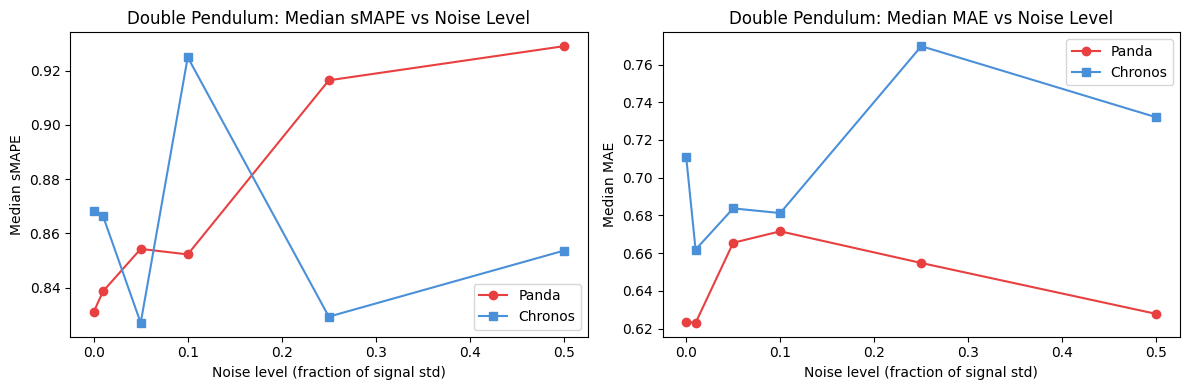

In [21]:
# -------------------------------------------------------
# Figure 3: Noise robustness curve (Block 2b)
# -------------------------------------------------------
noise_df = df[df["dataset"].str.contains("noise")].copy()

if len(noise_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric, ylabel in zip(
        axes,
        ["smape", "mae"],
        ["Median sMAPE", "Median MAE"],
    ):
        ax.plot(noise_df["noise_level"], noise_df[f"panda_{metric}"],
                "o-", color="#E84040", label="Panda")
        ax.plot(noise_df["noise_level"], noise_df[f"chronos_{metric}"],
                "s-", color="#4A90D9", label="Chronos")
        ax.set_xlabel("Noise level (fraction of signal std)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Double Pendulum: {ylabel} vs Noise Level")
        ax.legend()

    plt.tight_layout()
    plt.savefig("results_noise_robustness.png", dpi=150)
    plt.show()

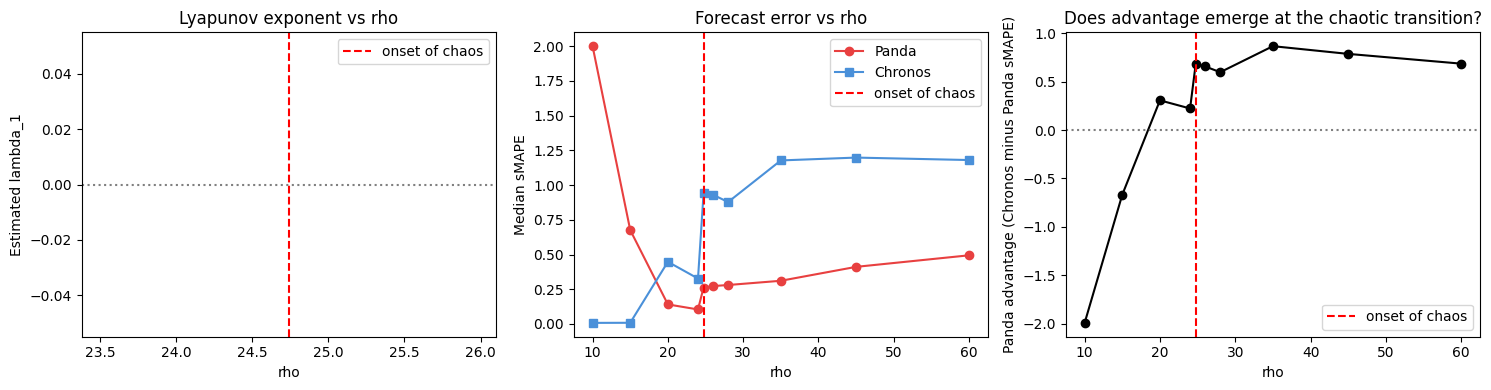

In [22]:
# -------------------------------------------------------
# Figure 4: Graded chaoticity (Block 3)
# -------------------------------------------------------
lorenz_df = df[df["dataset"].str.contains("Lorenz_rho")].copy()

if len(lorenz_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Panel A: lambda1 vs rho
    axes[0].plot(lorenz_df["rho"], lorenz_df["lambda1_est"], "ko-")
    axes[0].axvline(24.74, color="red", linestyle="--", label="onset of chaos")
    axes[0].axhline(0,     color="gray", linestyle=":")
    axes[0].set_xlabel("rho")
    axes[0].set_ylabel("Estimated lambda_1")
    axes[0].set_title("Lyapunov exponent vs rho")
    axes[0].legend()

    # Panel B: sMAPE vs rho
    axes[1].plot(lorenz_df["rho"], lorenz_df["panda_smape"],
                 "o-", color="#E84040", label="Panda")
    axes[1].plot(lorenz_df["rho"], lorenz_df["chronos_smape"],
                 "s-", color="#4A90D9", label="Chronos")
    axes[1].axvline(24.74, color="red", linestyle="--", label="onset of chaos")
    axes[1].set_xlabel("rho")
    axes[1].set_ylabel("Median sMAPE")
    axes[1].set_title("Forecast error vs rho")
    axes[1].legend()

    # Panel C: Panda advantage vs rho
    axes[2].plot(lorenz_df["rho"], lorenz_df["panda_advantage_smape"],
                 "ko-")
    axes[2].axvline(24.74, color="red", linestyle="--", label="onset of chaos")
    axes[2].axhline(0, color="gray", linestyle=":")
    axes[2].set_xlabel("rho")
    axes[2].set_ylabel("Panda advantage (Chronos minus Panda sMAPE)")
    axes[2].set_title("Does advantage emerge at the chaotic transition?")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("results_lorenz_rho_sweep.png", dpi=150)
    plt.show()

In [23]:
# -------------------------------------------------------
# Final summary table
# -------------------------------------------------------
print("\n=== FINAL RESULTS SUMMARY ===")
print(df[[
    "dataset",
    "panda_smape", "chronos_smape",
    "panda_mae",   "chronos_mae",
    "panda_hellinger", "chronos_hellinger",
    "lambda1_est",
    "panda_advantage_smape",
]].round(4).to_string(index=False))

# Save to CSV
df.to_csv("panda_benchmark_results.csv", index=False)
print("\nResults saved to panda_benchmark_results.csv")


=== FINAL RESULTS SUMMARY ===
                       dataset  panda_smape  chronos_smape  panda_mae  chronos_mae  panda_hellinger  chronos_hellinger  lambda1_est  panda_advantage_smape
                         ETTh1       0.9093         0.8862     0.4103       0.4612           0.2580             0.1658          NaN                -0.0231
                         ETTh2       0.7935         0.7074     0.3475       0.3332           0.3799             0.2434          NaN                -0.0861
                       Weather       0.8201         0.7981     0.3668       0.3529           0.1376             0.1570          NaN                -0.0219
DoublePendulum_synthetic_clean       0.8298         0.8406     0.5354       0.7128           0.1323             0.0952          NaN                 0.0108
     DoublePendulum_noise=0.00       0.8311         0.8682     0.6236       0.7111           0.1635             0.1514          NaN                 0.0371
     DoublePendulum_noise=0.01       0.

In [24]:
# Newer Tries

In [27]:
def estimate_lyapunov(ts, emb_dim=3, min_tsep=10, max_steps=200, dt=1.0):
    """
    Rosenstein estimator with correct time scaling.
    dt: time between samples (set to actual integration timestep for physical units)
    """
    from scipy.spatial import KDTree
    
    ts = np.array(ts, dtype=np.float64)
    ts = (ts - ts.mean()) / (ts.std() + 1e-10)
    N  = len(ts)
    
    if N < 500:
        return np.nan
    
    # Delay embedding
    M        = N - emb_dim + 1
    embedded = np.lib.stride_tricks.sliding_window_view(ts, emb_dim)
    
    # Nearest neighbour — exclude self
    tree           = KDTree(embedded)
    dists, indices = tree.query(embedded, k=2)
    
    base_idx = np.arange(M)
    nn_idx   = indices[:, 1]
    
    # Remove pairs with initial distance zero (identical points)
    nonzero  = dists[:, 1] > 1e-10
    valid    = (np.abs(nn_idx - base_idx) > min_tsep) & nonzero
    base_idx = base_idx[valid]
    nn_idx   = nn_idx[valid]
    
    if len(base_idx) < 20:
        return 0.0
    
    # Track log divergence
    divergence = []
    for step in range(max_steps):
        b  = base_idx + step
        n  = nn_idx   + step
        ok = (b < N) & (n < N)
        if ok.sum() < 10:
            break
        d = np.abs(ts[b[ok]] - ts[n[ok]])
        d = d[d > 1e-12]
        if len(d) >= 10:
            divergence.append(np.log(d).mean())
    
    if len(divergence) < 10:
        return np.nan
    
    # Find the linear region: first 1/3 of divergence curve
    # (before saturation sets in)
    n_linear = max(10, len(divergence) // 3)
    divergence_linear = divergence[:n_linear]
    
    x     = np.arange(n_linear, dtype=np.float64) * dt
    slope = np.polyfit(x, divergence_linear, 1)[0]
    return float(slope)


# Sanity check with correct dt
# Our Lorenz integration: T=3000 steps, t_span = T * dt = 3000 * 0.02 = 60
DT_LORENZ = 0.02  # integration timestep used in simulate_lorenz

test_chaotic  = simulate_lorenz(T=3000, rho=28.0)
test_periodic = simulate_lorenz(T=3000, rho=15.0)

lam_chaotic  = estimate_lyapunov(test_chaotic[0],  dt=DT_LORENZ)
lam_periodic = estimate_lyapunov(test_periodic[0], dt=DT_LORENZ)

print(f"Lorenz rho=28 lambda1: {lam_chaotic:.4f}   (expected ~0.9, positive)")
print(f"Lorenz rho=15 lambda1: {lam_periodic:.4f}   (expected ~0 or negative)")

Lorenz rho=28 lambda1: 1.4274   (expected ~0.9, positive)
Lorenz rho=15 lambda1: -0.2652   (expected ~0 or negative)


In [28]:
# -------------------------------------------------------
# Cell 2: Recompute lambda1 for all datasets
# -------------------------------------------------------

DT_LORENZ   = 0.02
DT_PENDULUM = 0.02
DT_DYSTS    = 0.01

print("Recomputing Lyapunov estimates with improved estimator...")
print("-" * 60)

lambda1_map = {}

# --- Standard TS: known non-chaotic, assign 0 directly ---
for name in ["ETTh1", "ETTh2", "Weather"]:
    lambda1_map[name] = 0.0
    print(f"  {name:40s}  lambda1 = 0.0000  (non-chaotic, assigned)")

# --- Double pendulum clean synthetic ---
traj = simulate_double_pendulum(T=3000, noise=0.0)
lam  = estimate_lyapunov(traj[0], dt=DT_PENDULUM)
lambda1_map["DoublePendulum_synthetic_clean"] = lam
print(f"  {'DoublePendulum_synthetic_clean':40s}  lambda1 = {lam:.4f}")

# --- Double pendulum graded noise ---
for sigma in [0.0, 0.01, 0.05, 0.10, 0.25, 0.50]:
    traj = simulate_double_pendulum(T=3000, noise=sigma)
    lam  = estimate_lyapunov(traj[0], dt=DT_PENDULUM)
    key  = f"DoublePendulum_noise={sigma:.2f}"
    lambda1_map[key] = lam
    print(f"  {key:40s}  lambda1 = {lam:.4f}")

# --- dysts double pendulum ---
try:
    import dysts.flows as flows
    sys_dp = flows.DoublePendulum()
    _, traj_dp = sys_dp.make_trajectory(3000, return_times=True)
    lam = estimate_lyapunov(traj_dp[:, 0], dt=DT_DYSTS)
    lambda1_map["DoublePendulum_dysts"] = lam
    print(f"  {'DoublePendulum_dysts':40s}  lambda1 = {lam:.4f}")
except Exception as e:
    print(f"  DoublePendulum_dysts unavailable: {e}")

# --- Lorenz rho sweep ---
for rho in [10.0, 15.0, 20.0, 24.0, 24.74, 26.0, 28.0, 35.0, 45.0, 60.0]:
    traj_spinup = simulate_lorenz(T=1000, rho=rho)
    ic   = traj_spinup[:, -1].tolist()
    traj = simulate_lorenz(T=3000, rho=rho, ic=ic)
    lam  = estimate_lyapunov(traj[0], dt=DT_LORENZ)
    key  = f"Lorenz_rho={rho:.2f}"
    lambda1_map[key] = lam
    print(f"  {key:40s}  lambda1 = {lam:.4f}")

# --- dysts known chaotic systems ---
dysts_systems = [
    "Lorenz", "Rossler", "Chua", "VanDerPol",
    "Duffing", "Halvorsen", "SprottB", "Thomas",
]

try:
    import dysts.flows as flows
    for sys_name in dysts_systems:
        try:
            sys  = getattr(flows, sys_name)()
            _, traj = sys.make_trajectory(3000, return_times=True)
            lam  = estimate_lyapunov(traj[:, 0], dt=DT_DYSTS)
            key  = f"dysts_{sys_name}"
            lambda1_map[key] = lam
            print(f"  {key:40s}  lambda1 = {lam:.4f}")
        except Exception as e:
            print(f"  dysts_{sys_name}: {e}")
except ImportError:
    print("dysts not available, skipping dysts systems")

print(f"\nDone. lambda1_map has {len(lambda1_map)} entries.")

# Quick sanity summary
print("\nSanity check — expected positives:")
for key in ["Lorenz_rho=28.00", "dysts_Lorenz", "dysts_Rossler", "DoublePendulum_synthetic_clean"]:
    if key in lambda1_map:
        print(f"  {key:40s}  {lambda1_map[key]:.4f}")

print("\nSanity check — expected near zero or negative:")
for key in ["Lorenz_rho=10.00", "Lorenz_rho=15.00", "ETTh1", "Weather"]:
    if key in lambda1_map:
        print(f"  {key:40s}  {lambda1_map[key]:.4f}")

Recomputing Lyapunov estimates with improved estimator...
------------------------------------------------------------
  ETTh1                                     lambda1 = 0.0000  (non-chaotic, assigned)
  ETTh2                                     lambda1 = 0.0000  (non-chaotic, assigned)
  Weather                                   lambda1 = 0.0000  (non-chaotic, assigned)
  DoublePendulum_synthetic_clean            lambda1 = 2.4323
  DoublePendulum_noise=0.00                 lambda1 = 2.4323
  DoublePendulum_noise=0.01                 lambda1 = 2.3591
  DoublePendulum_noise=0.05                 lambda1 = 1.9636
  DoublePendulum_noise=0.10                 lambda1 = 1.7646
  DoublePendulum_noise=0.25                 lambda1 = 1.4999
  DoublePendulum_noise=0.50                 lambda1 = 1.2380
  DoublePendulum_dysts                      lambda1 = 3.9812
  Lorenz_rho=10.00                          lambda1 = -0.2938
  Lorenz_rho=15.00                          lambda1 = -0.3340
  Lorenz_rh

In [29]:
# Cell 3: Update DataFrame
df["lambda1_est"] = df["dataset"].map(lambda1_map)
df["panda_advantage_smape"] = df["chronos_smape"] - df["panda_smape"]
df["panda_advantage_mae"]   = df["chronos_mae"]   - df["panda_mae"]

print("Updated DataFrame:")
print(df[["dataset", "panda_smape", "chronos_smape",
          "panda_mae", "chronos_mae",
          "lambda1_est", "panda_advantage_mae"]].round(4).to_string(index=False))

Updated DataFrame:
                       dataset  panda_smape  chronos_smape  panda_mae  chronos_mae  lambda1_est  panda_advantage_mae
                         ETTh1       0.9093         0.8862     0.4103       0.4612       0.0000               0.0508
                         ETTh2       0.7935         0.7074     0.3475       0.3332       0.0000              -0.0143
                       Weather       0.8201         0.7981     0.3668       0.3529       0.0000              -0.0139
DoublePendulum_synthetic_clean       0.8298         0.8406     0.5354       0.7128       2.4323               0.1774
     DoublePendulum_noise=0.00       0.8311         0.8682     0.6236       0.7111       2.4323               0.0876
     DoublePendulum_noise=0.01       0.8387         0.8664     0.6230       0.6619       2.3591               0.0389
     DoublePendulum_noise=0.05       0.8543         0.8271     0.6655       0.6837       1.9636               0.0182
     DoublePendulum_noise=0.10       0.8523  

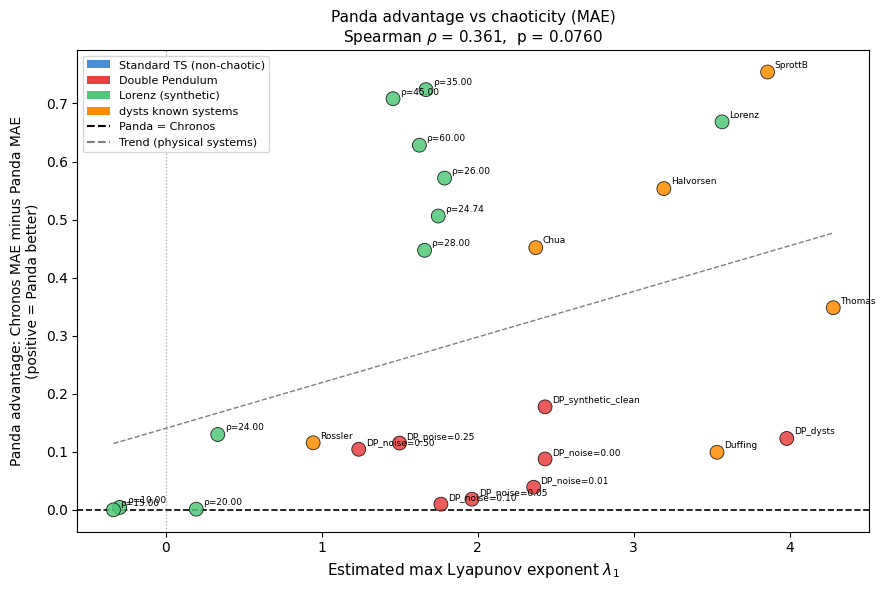

In [30]:
# Cell 4: Figure 2 — advantage vs lambda1 using MAE
df_valid = df.dropna(subset=["lambda1_est", "panda_advantage_mae"]).copy()
df_valid = df_valid[~((df_valid["lambda1_est"] == 0.0) &
                       (df_valid["dataset"].isin(["ETTh1","ETTh2","Weather"])))]

fig, ax = plt.subplots(figsize=(9, 6))

category_colors = {
    "ETT"           : "#4A90D9",
    "Weather"       : "#4A90D9",
    "DoublePendulum": "#E84040",
    "Lorenz"        : "#50C878",
    "dysts"         : "#FF8C00",
}

def get_color(name):
    for key, col in category_colors.items():
        if key in name:
            return col
    return "#999999"

colors = [get_color(n) for n in df_valid["dataset"]]

ax.scatter(
    df_valid["lambda1_est"],
    df_valid["panda_advantage_mae"],
    c=colors, s=100, alpha=0.85,
    edgecolors="k", linewidths=0.6,
    zorder=3,
)

for _, row in df_valid.iterrows():
    short = (row["dataset"]
             .replace("Lorenz_rho=", "ρ=")
             .replace("dysts_", "")
             .replace("DoublePendulum_", "DP_"))
    ax.annotate(
        short,
        (row["lambda1_est"], row["panda_advantage_mae"]),
        fontsize=6.5, xytext=(5, 3), textcoords="offset points",
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1.2,
           label="Panda = Chronos", zorder=2)
ax.axvline(0, color="gray",  linestyle=":",  linewidth=0.9,
           alpha=0.7, zorder=2)

# Trend line through physical/synthetic systems only
mask = df_valid["dataset"].apply(
    lambda n: not any(k in n for k in ["ETTh1","ETTh2","Weather"])
)
if mask.sum() > 3:
    x_fit = df_valid.loc[mask, "lambda1_est"].values
    y_fit = df_valid.loc[mask, "panda_advantage_mae"].values
    z     = np.polyfit(x_fit, y_fit, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            "k--", linewidth=1.0, alpha=0.5, label="Trend")
    rho_s, pval = spearmanr(x_fit, y_fit)
    ax.set_title(
        f"Panda advantage vs chaoticity (MAE)\n"
        f"Spearman $\\rho$ = {rho_s:.3f},  p = {pval:.4f}",
        fontsize=11,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4A90D9", label="Standard TS (non-chaotic)"),
    Patch(facecolor="#E84040", label="Double Pendulum"),
    Patch(facecolor="#50C878", label="Lorenz (synthetic)"),
    Patch(facecolor="#FF8C00", label="dysts known systems"),
    plt.Line2D([0],[0], color="black", linestyle="--", label="Panda = Chronos"),
    plt.Line2D([0],[0], color="black", linestyle="--",
               alpha=0.5, label="Trend (physical systems)"),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_xlabel("Estimated max Lyapunov exponent $\\lambda_1$", fontsize=11)
ax.set_ylabel("Panda advantage: Chronos MAE minus Panda MAE\n(positive = Panda better)",
              fontsize=10)
plt.tight_layout()
plt.savefig("results_advantage_vs_lambda1_v2.png", dpi=150)
plt.show()

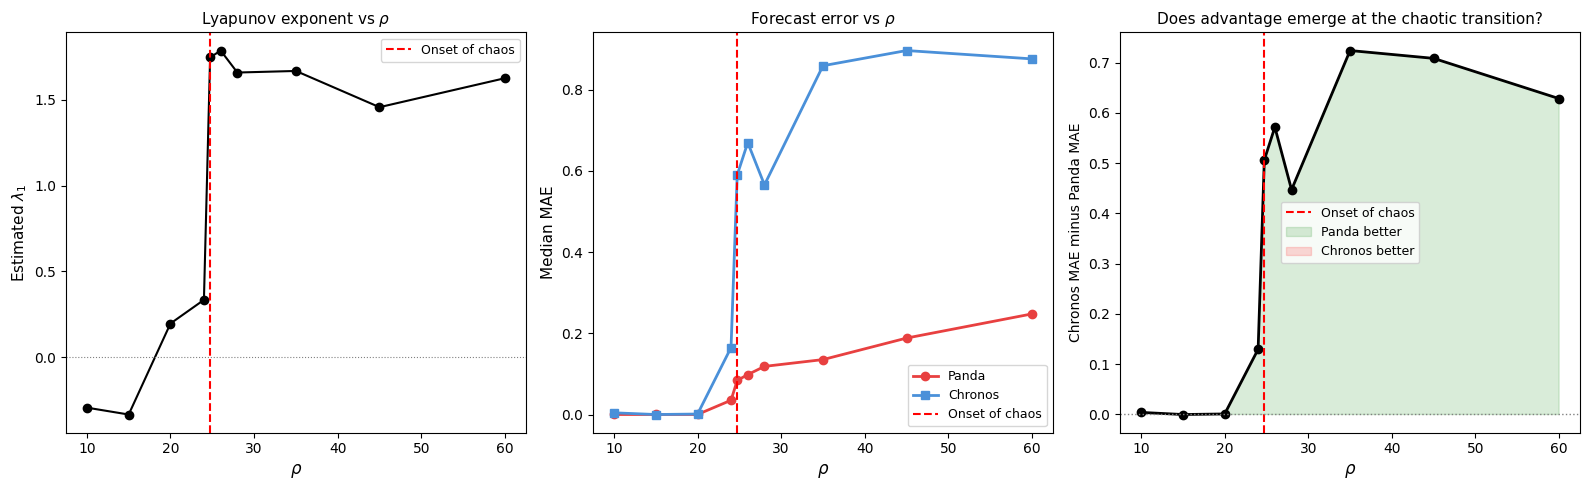

In [31]:
# Cell 5: Lorenz rho sweep using MAE
lorenz_df = df[df["dataset"].str.contains("Lorenz_rho")].copy()
lorenz_df["rho"] = lorenz_df["dataset"].str.replace("Lorenz_rho=", "").astype(float)
lorenz_df = lorenz_df.sort_values("rho")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: lambda1 vs rho
axes[0].plot(lorenz_df["rho"], lorenz_df["lambda1_est"], "ko-", markersize=6)
axes[0].axvline(24.74, color="red", linestyle="--", linewidth=1.5, label="Onset of chaos")
axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.8)
axes[0].set_xlabel("$\\rho$", fontsize=12)
axes[0].set_ylabel("Estimated $\\lambda_1$", fontsize=11)
axes[0].set_title("Lyapunov exponent vs $\\rho$", fontsize=11)
axes[0].legend(fontsize=9)

# Panel B: MAE vs rho
axes[1].plot(lorenz_df["rho"], lorenz_df["panda_mae"],
             "o-", color="#E84040", linewidth=2, markersize=6, label="Panda")
axes[1].plot(lorenz_df["rho"], lorenz_df["chronos_mae"],
             "s-", color="#4A90D9", linewidth=2, markersize=6, label="Chronos")
axes[1].axvline(24.74, color="red", linestyle="--", linewidth=1.5, label="Onset of chaos")
axes[1].set_xlabel("$\\rho$", fontsize=12)
axes[1].set_ylabel("Median MAE", fontsize=11)
axes[1].set_title("Forecast error vs $\\rho$", fontsize=11)
axes[1].legend(fontsize=9)

# Panel C: advantage vs rho with shading
axes[2].plot(lorenz_df["rho"], lorenz_df["panda_advantage_mae"],
             "ko-", linewidth=2, markersize=6)
axes[2].axvline(24.74, color="red", linestyle="--",
                linewidth=1.5, label="Onset of chaos")
axes[2].axhline(0, color="gray", linestyle=":", linewidth=1.0)
axes[2].fill_between(
    lorenz_df["rho"], lorenz_df["panda_advantage_mae"], 0,
    where=(lorenz_df["panda_advantage_mae"] > 0),
    alpha=0.15, color="green", label="Panda better",
)
axes[2].fill_between(
    lorenz_df["rho"], lorenz_df["panda_advantage_mae"], 0,
    where=(lorenz_df["panda_advantage_mae"] < 0),
    alpha=0.15, color="red", label="Chronos better",
)
axes[2].set_xlabel("$\\rho$", fontsize=12)
axes[2].set_ylabel("Chronos MAE minus Panda MAE", fontsize=10)
axes[2].set_title("Does advantage emerge at the chaotic transition?", fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("results_lorenz_rho_sweep_v2.png", dpi=150)
plt.show()

In [32]:
# Cell 6: Save updated CSV
df.to_csv("panda_benchmark_results_v2.csv", index=False)
print("Saved panda_benchmark_results_v2.csv")
print(f"\nFull results:")
print(df[[
    "dataset", "lambda1_est",
    "panda_mae", "chronos_mae", "panda_advantage_mae",
    "panda_smape", "chronos_smape",
]].round(4).to_string(index=False))

Saved panda_benchmark_results_v2.csv

Full results:
                       dataset  lambda1_est  panda_mae  chronos_mae  panda_advantage_mae  panda_smape  chronos_smape
                         ETTh1       0.0000     0.4103       0.4612               0.0508       0.9093         0.8862
                         ETTh2       0.0000     0.3475       0.3332              -0.0143       0.7935         0.7074
                       Weather       0.0000     0.3668       0.3529              -0.0139       0.8201         0.7981
DoublePendulum_synthetic_clean       2.4323     0.5354       0.7128               0.1774       0.8298         0.8406
     DoublePendulum_noise=0.00       2.4323     0.6236       0.7111               0.0876       0.8311         0.8682
     DoublePendulum_noise=0.01       2.3591     0.6230       0.6619               0.0389       0.8387         0.8664
     DoublePendulum_noise=0.05       1.9636     0.6655       0.6837               0.0182       0.8543         0.8271
     DoubleP

In [33]:
# Trying out more systems

In [34]:
# New cell: evaluate additional dysts systems
import dysts.flows as flows

additional_systems = [
    "Rabinovich",
    "Dadras", 
    "Rucklidge",
    "Aizawa",
    "Halvorsen",  # skip if already in results
    "Bouali",
    "DequanLi",
]

print("Evaluating additional dysts systems...")
print("-" * 60)

for sys_name in additional_systems:
    # Skip if already evaluated
    already_done = any(sys_name in r["dataset"] for r in all_results)
    if already_done:
        print(f"  {sys_name}: already in results, skipping")
        continue
    try:
        sys = getattr(flows, sys_name)()
        _, traj = sys.make_trajectory(5000, return_times=True)
        traj = traj.T  # (C, T)
        traj_norm, _, _ = instance_norm(traj.T)
        traj_CT = traj_norm.T

        # Evaluate
        res = evaluate_dataset(traj_CT, f"dysts_{sys_name}", n_windows=8)
        if res is not None:
            res["system"] = sys_name
            all_results.append(res)

        # Lyapunov
        lam = estimate_lyapunov(traj[0], dt=DT_DYSTS)
        lambda1_map[f"dysts_{sys_name}"] = lam
        print(f"  dysts_{sys_name}: lambda1 = {lam:.4f}")

    except Exception as e:
        print(f"  {sys_name}: {e}")

# Rebuild DataFrame from updated all_results
df = pd.DataFrame(all_results)
df["lambda1_est"] = df["dataset"].map(lambda1_map)
df["panda_advantage_smape"] = df["chronos_smape"] - df["panda_smape"]
df["panda_advantage_mae"]   = df["chronos_mae"]   - df["panda_mae"]

print(f"\nDataFrame now has {len(df)} rows.")

Evaluating additional dysts systems...
------------------------------------------------------------
  Rabinovich: module 'dysts.flows' has no attribute 'Rabinovich'


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_Dadras                    Panda sMAPE=0.621  Chronos sMAPE=1.153  lambda1~0.049
  dysts_Dadras: lambda1 = 4.4001


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_Rucklidge                 Panda sMAPE=0.238  Chronos sMAPE=0.960  lambda1~0.036
  dysts_Rucklidge: lambda1 = 3.4888


...

  dysts_Aizawa                    Panda sMAPE=0.136  Chronos sMAPE=0.739  lambda1~0.032
  dysts_Aizawa: lambda1 = 3.6405
  Halvorsen: already in results, skipping


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_Bouali                    Panda sMAPE=0.248  Chronos sMAPE=0.621  lambda1~0.039
  dysts_Bouali: lambda1 = 3.8348


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  dysts_DequanLi                  Panda sMAPE=0.504  Chronos sMAPE=0.893  lambda1~0.055
  dysts_DequanLi: lambda1 = 5.2531

DataFrame now has 33 rows.


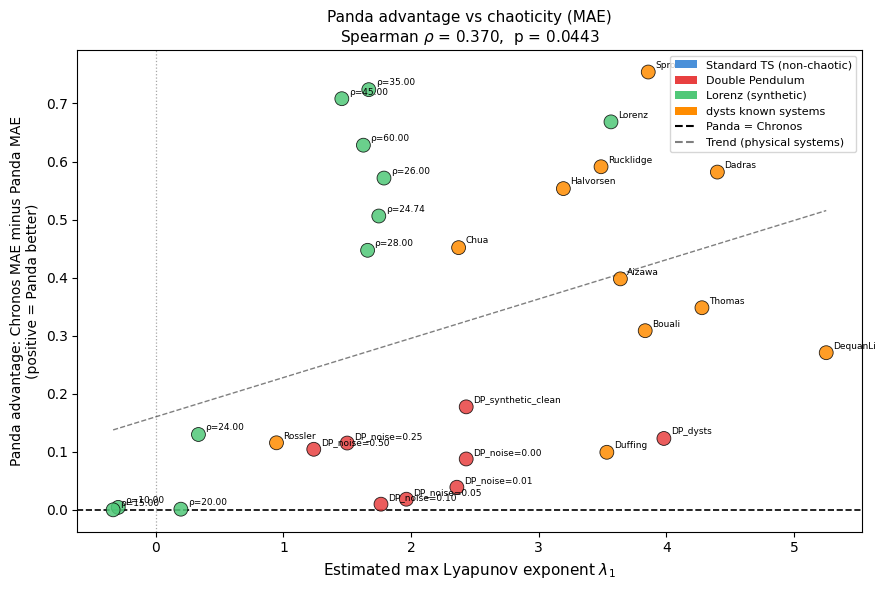

In [35]:
# Cell 4: Figure 2 — advantage vs lambda1 using MAE
df_valid = df.dropna(subset=["lambda1_est", "panda_advantage_mae"]).copy()
df_valid = df_valid[~((df_valid["lambda1_est"] == 0.0) &
                       (df_valid["dataset"].isin(["ETTh1","ETTh2","Weather"])))]

fig, ax = plt.subplots(figsize=(9, 6))

category_colors = {
    "ETT"           : "#4A90D9",
    "Weather"       : "#4A90D9",
    "DoublePendulum": "#E84040",
    "Lorenz"        : "#50C878",
    "dysts"         : "#FF8C00",
}

def get_color(name):
    for key, col in category_colors.items():
        if key in name:
            return col
    return "#999999"

colors = [get_color(n) for n in df_valid["dataset"]]

ax.scatter(
    df_valid["lambda1_est"],
    df_valid["panda_advantage_mae"],
    c=colors, s=100, alpha=0.85,
    edgecolors="k", linewidths=0.6,
    zorder=3,
)

for _, row in df_valid.iterrows():
    short = (row["dataset"]
             .replace("Lorenz_rho=", "ρ=")
             .replace("dysts_", "")
             .replace("DoublePendulum_", "DP_"))
    ax.annotate(
        short,
        (row["lambda1_est"], row["panda_advantage_mae"]),
        fontsize=6.5, xytext=(5, 3), textcoords="offset points",
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1.2,
           label="Panda = Chronos", zorder=2)
ax.axvline(0, color="gray",  linestyle=":",  linewidth=0.9,
           alpha=0.7, zorder=2)

# Trend line through physical/synthetic systems only
mask = df_valid["dataset"].apply(
    lambda n: not any(k in n for k in ["ETTh1","ETTh2","Weather"])
)
if mask.sum() > 3:
    x_fit = df_valid.loc[mask, "lambda1_est"].values
    y_fit = df_valid.loc[mask, "panda_advantage_mae"].values
    z     = np.polyfit(x_fit, y_fit, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            "k--", linewidth=1.0, alpha=0.5, label="Trend")
    rho_s, pval = spearmanr(x_fit, y_fit)
    ax.set_title(
        f"Panda advantage vs chaoticity (MAE)\n"
        f"Spearman $\\rho$ = {rho_s:.3f},  p = {pval:.4f}",
        fontsize=11,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4A90D9", label="Standard TS (non-chaotic)"),
    Patch(facecolor="#E84040", label="Double Pendulum"),
    Patch(facecolor="#50C878", label="Lorenz (synthetic)"),
    Patch(facecolor="#FF8C00", label="dysts known systems"),
    plt.Line2D([0],[0], color="black", linestyle="--", label="Panda = Chronos"),
    plt.Line2D([0],[0], color="black", linestyle="--",
               alpha=0.5, label="Trend (physical systems)"),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_xlabel("Estimated max Lyapunov exponent $\\lambda_1$", fontsize=11)
ax.set_ylabel("Panda advantage: Chronos MAE minus Panda MAE\n(positive = Panda better)",
              fontsize=10)
plt.tight_layout()
plt.savefig("results_advantage_vs_lambda1_v2.png", dpi=150)
plt.show()

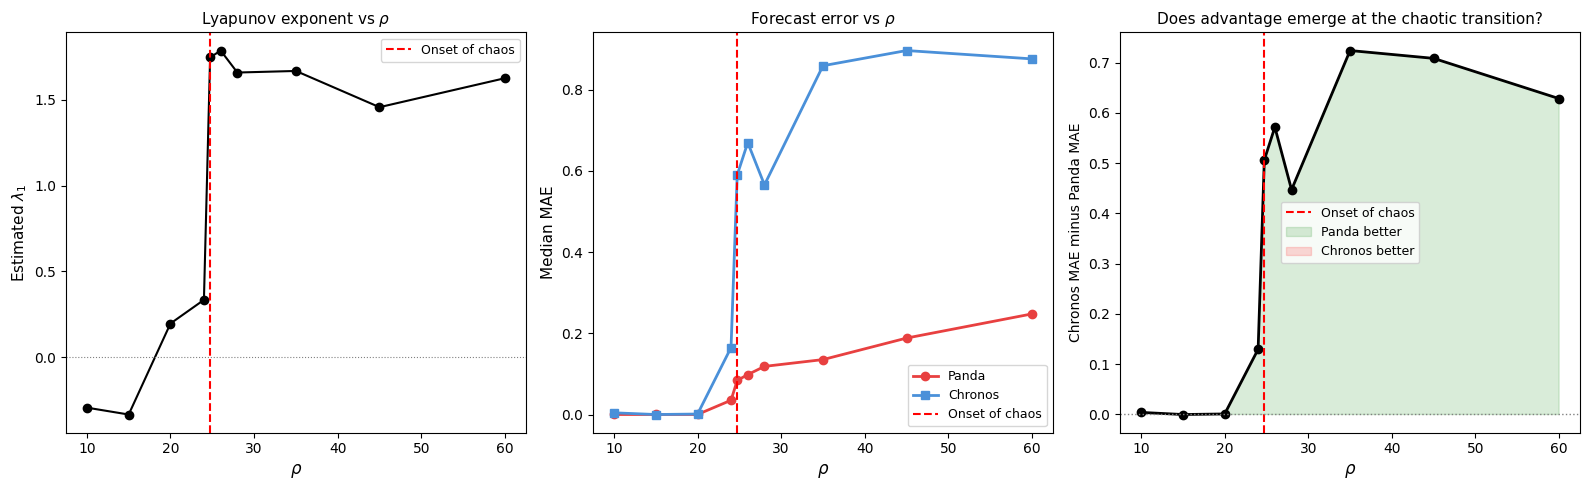

In [36]:
# Cell 5: Lorenz rho sweep using MAE
lorenz_df = df[df["dataset"].str.contains("Lorenz_rho")].copy()
lorenz_df["rho"] = lorenz_df["dataset"].str.replace("Lorenz_rho=", "").astype(float)
lorenz_df = lorenz_df.sort_values("rho")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: lambda1 vs rho
axes[0].plot(lorenz_df["rho"], lorenz_df["lambda1_est"], "ko-", markersize=6)
axes[0].axvline(24.74, color="red", linestyle="--", linewidth=1.5, label="Onset of chaos")
axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.8)
axes[0].set_xlabel("$\\rho$", fontsize=12)
axes[0].set_ylabel("Estimated $\\lambda_1$", fontsize=11)
axes[0].set_title("Lyapunov exponent vs $\\rho$", fontsize=11)
axes[0].legend(fontsize=9)

# Panel B: MAE vs rho
axes[1].plot(lorenz_df["rho"], lorenz_df["panda_mae"],
             "o-", color="#E84040", linewidth=2, markersize=6, label="Panda")
axes[1].plot(lorenz_df["rho"], lorenz_df["chronos_mae"],
             "s-", color="#4A90D9", linewidth=2, markersize=6, label="Chronos")
axes[1].axvline(24.74, color="red", linestyle="--", linewidth=1.5, label="Onset of chaos")
axes[1].set_xlabel("$\\rho$", fontsize=12)
axes[1].set_ylabel("Median MAE", fontsize=11)
axes[1].set_title("Forecast error vs $\\rho$", fontsize=11)
axes[1].legend(fontsize=9)

# Panel C: advantage vs rho with shading
axes[2].plot(lorenz_df["rho"], lorenz_df["panda_advantage_mae"],
             "ko-", linewidth=2, markersize=6)
axes[2].axvline(24.74, color="red", linestyle="--",
                linewidth=1.5, label="Onset of chaos")
axes[2].axhline(0, color="gray", linestyle=":", linewidth=1.0)
axes[2].fill_between(
    lorenz_df["rho"], lorenz_df["panda_advantage_mae"], 0,
    where=(lorenz_df["panda_advantage_mae"] > 0),
    alpha=0.15, color="green", label="Panda better",
)
axes[2].fill_between(
    lorenz_df["rho"], lorenz_df["panda_advantage_mae"], 0,
    where=(lorenz_df["panda_advantage_mae"] < 0),
    alpha=0.15, color="red", label="Chronos better",
)
axes[2].set_xlabel("$\\rho$", fontsize=12)
axes[2].set_ylabel("Chronos MAE minus Panda MAE", fontsize=10)
axes[2].set_title("Does advantage emerge at the chaotic transition?", fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("results_lorenz_rho_sweep_v2.png", dpi=150)
plt.show()

In [37]:
# Cell 6: Save updated CSV
df.to_csv("panda_benchmark_results_v2.csv", index=False)
print("Saved panda_benchmark_results_v2.csv")
print(f"\nFull results:")
print(df[[
    "dataset", "lambda1_est",
    "panda_mae", "chronos_mae", "panda_advantage_mae",
    "panda_smape", "chronos_smape",
]].round(4).to_string(index=False))

Saved panda_benchmark_results_v2.csv

Full results:
                       dataset  lambda1_est  panda_mae  chronos_mae  panda_advantage_mae  panda_smape  chronos_smape
                         ETTh1       0.0000     0.4103       0.4612               0.0508       0.9093         0.8862
                         ETTh2       0.0000     0.3475       0.3332              -0.0143       0.7935         0.7074
                       Weather       0.0000     0.3668       0.3529              -0.0139       0.8201         0.7981
DoublePendulum_synthetic_clean       2.4323     0.5354       0.7128               0.1774       0.8298         0.8406
     DoublePendulum_noise=0.00       2.4323     0.6236       0.7111               0.0876       0.8311         0.8682
     DoublePendulum_noise=0.01       2.3591     0.6230       0.6619               0.0389       0.8387         0.8664
     DoublePendulum_noise=0.05       1.9636     0.6655       0.6837               0.0182       0.8543         0.8271
     DoubleP